In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import TRAIN_PATH, TEST_PATH, SAMPLE_SUBMISSION_PATH, TARGET, ID_COL

In [10]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


In [11]:
train.head()

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [12]:
test.head()

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


In [5]:
sample_submission.head()

,id,bilissel_performans_skoru
0,1,7.85
1,2,4.32


In [13]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']

Test columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']


In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

In [15]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          24000 non-null  int64  
 2   cinsiyet                     24000 non-null  object 
 3   meslek                       23378 non-null  object 
 4   vucut_kitle_indeksi          23352 non-null  float64
 5   ulke                         24000 non-null  object 
 6   rem_yuzdesi                  24000 non-null  float64
 7   derin_uyku_yuzdesi           24000 non-null  float64
 8   uykuya_dalma_suresi_dk       24000 non-null  int64  
 9   gecelik_uyanma_sayisi        24000 non-null  int64  
 10  uyku_oncesi_kafein_mg        23303 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  24000 non-null  int64  
 12  gunluk_adim_sayisi           24000 non-null  int64  
 13  sekerleme_suresi

In [16]:
train.describe(include="object").T

,count,unique,top,freq
cinsiyet,56000,2,Kadin,28676
meslek,54622,11,Saglik Personeli,9842
ulke,56000,15,Ingiltere,11324
kronotip,54032,3,Notr,24594
ruh_sagligi_durumu,54904,4,Saglikli,38365
mevsim,56000,2,Ilkbahar-Yaz,28143
gun_tipi,56000,2,Hafta ici,40052


In [17]:
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

missing_df = pd.DataFrame({
    "train_missing": missing_train,
    "train_missing_ratio": missing_train / len(train),
    "test_missing": missing_test,
    "test_missing_ratio": missing_test / len(test)
})

missing_df = missing_df[
    (missing_df["train_missing"] > 0) | 
    (missing_df["test_missing"] > 0)
].sort_values("train_missing", ascending=False)

missing_df

,train_missing,train_missing_ratio,test_missing,test_missing_ratio
kronotip,1968,0.035143,832.0,0.034667
vucut_kitle_indeksi,1752,0.031286,648.0,0.027000
stres_skoru,1715,0.030625,765.0,0.031875
uyku_oncesi_kafein_mg,1463,0.026125,697.0,0.029042
meslek,1378,0.024607,622.0,0.025917
ruh_sagligi_durumu,1096,0.019571,504.0,0.021000


In [18]:
train[TARGET].describe()

count    56000.000000
mean         5.913096
std          2.231759
min          0.000000
25%          4.397431
50%          6.032249
75%          7.574980
max         10.000000
Name: bilissel_performans_skoru, dtype: float64

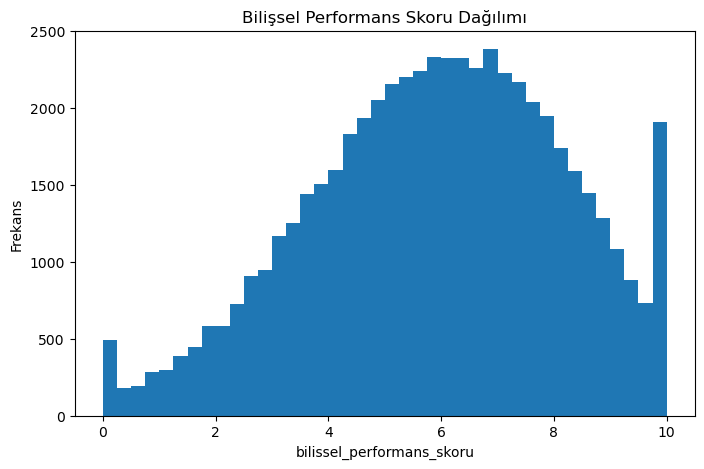

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(train[TARGET], bins=40)
plt.title("Bilişsel Performans Skoru Dağılımı")
plt.xlabel(TARGET)
plt.ylabel("Frekans")
plt.show()

In [20]:
print("Min target:", train[TARGET].min())
print("Max target:", train[TARGET].max())

print("0'dan küçük değer sayısı:", (train[TARGET] < 0).sum())
print("10'dan büyük değer sayısı:", (train[TARGET] > 10).sum())

Min target: 0.0
Max target: 10.0
0'dan küçük değer sayısı: 0
10'dan büyük değer sayısı: 0


In [21]:
numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

numeric_cols = [col for col in numeric_cols if col not in [ID_COL, TARGET]]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

print("Numeric column count:", len(numeric_cols))
print("Categorical column count:", len(categorical_cols))

Numeric columns: ['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat']
Categorical columns: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']
Numeric column count: 15
Categorical column count: 7


In [22]:
corr_with_target = train[numeric_cols + [TARGET]].corr(numeric_only=True)[TARGET]
corr_with_target = corr_with_target.drop(TARGET).sort_values(ascending=False)

corr_with_target

rem_yuzdesi                    0.442999
derin_uyku_yuzdesi             0.280006
gunluk_adim_sayisi             0.134042
hafta_sonu_uyku_farki_saat    -0.001648
oda_sicakligi_celsius         -0.011992
sekerleme_suresi_dk           -0.023683
vucut_kitle_indeksi           -0.037990
uyku_oncesi_ekran_suresi_dk   -0.044631
uyku_oncesi_kafein_mg         -0.062387
yas                           -0.070659
dinlenik_nabiz_bpm            -0.089389
uykuya_dalma_suresi_dk        -0.207349
gecelik_uyanma_sayisi         -0.270349
gunluk_calisma_saati          -0.342112
stres_skoru                   -0.586676
Name: bilissel_performans_skoru, dtype: float64

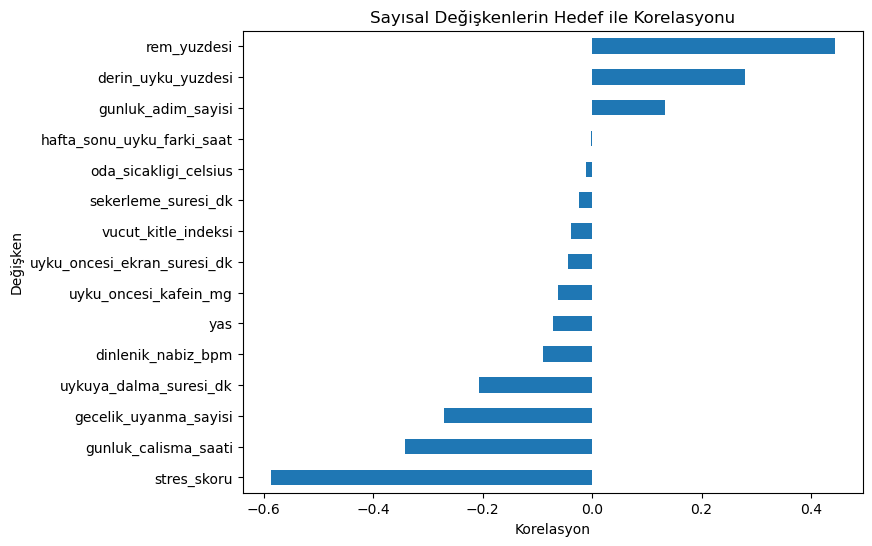

In [23]:
plt.figure(figsize=(8, 6))
corr_with_target.sort_values().plot(kind="barh")
plt.title("Sayısal Değişkenlerin Hedef ile Korelasyonu")
plt.xlabel("Korelasyon")
plt.ylabel("Değişken")
plt.show()

In [24]:
corr_with_target.sort_values(ascending=False).head(10)

rem_yuzdesi                    0.442999
derin_uyku_yuzdesi             0.280006
gunluk_adim_sayisi             0.134042
hafta_sonu_uyku_farki_saat    -0.001648
oda_sicakligi_celsius         -0.011992
sekerleme_suresi_dk           -0.023683
vucut_kitle_indeksi           -0.037990
uyku_oncesi_ekran_suresi_dk   -0.044631
uyku_oncesi_kafein_mg         -0.062387
yas                           -0.070659
Name: bilissel_performans_skoru, dtype: float64

In [25]:
corr_with_target.sort_values(ascending=True).head(10)

stres_skoru                   -0.586676
gunluk_calisma_saati          -0.342112
gecelik_uyanma_sayisi         -0.270349
uykuya_dalma_suresi_dk        -0.207349
dinlenik_nabiz_bpm            -0.089389
yas                           -0.070659
uyku_oncesi_kafein_mg         -0.062387
uyku_oncesi_ekran_suresi_dk   -0.044631
vucut_kitle_indeksi           -0.037990
sekerleme_suresi_dk           -0.023683
Name: bilissel_performans_skoru, dtype: float64

In [26]:
for col in categorical_cols:
    print("=" * 80)
    print(col)
    
    display(
        train.groupby(col)[TARGET]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )

cinsiyet


,count,mean,median,std
cinsiyet,,,,
Erkek,27324,5.913804,6.02978,2.224613
Kadin,28676,5.912420,6.03498,2.238586


meslek


,count,mean,median,std
meslek,,,,
Emekli,3778,7.935044,8.140140,1.608945
Ev Hanimi,3224,7.055969,7.234872,1.802786
Serbest Calisan,3812,6.985534,7.200061,1.870769
Egitimci,4395,6.343725,6.506638,2.011186
Muhendis,6533,6.223087,6.327394,2.040621
Satis ve Pazarlama Calisani,3899,6.010286,6.147973,2.055236
Yonetici,4454,5.729820,5.781396,2.127878
Ogrenci,8132,5.535248,5.601813,2.111092
Lojistik Calisani,3811,5.119135,5.218837,2.166604


ulke


...

,count,mean,median,std
ruh_sagligi_durumu,,,,
Saglikli,38365,6.491822,6.621904,2.018310
Anksiyete,8270,5.012262,5.093158,2.097732
Depresyon,5504,4.394400,4.509263,2.011677
Anksiyete ve depresyon,2765,3.590186,3.613890,2.046661


mevsim


,count,mean,median,std
mevsim,,,,
Sonbahar-Kis,27857,5.915958,6.026709,2.225839
Ilkbahar-Yaz,28143,5.910262,6.040667,2.237640


gun_tipi


,count,mean,median,std
gun_tipi,,,,
Hafta sonu,15948,6.993307,7.216302,1.938364
Hafta ici,40052,5.482975,5.542429,2.195082


In [27]:
cat_unique_df = pd.DataFrame({
    "column": categorical_cols,
    "unique_count": [train[col].nunique() for col in categorical_cols],
    "unique_values": [train[col].dropna().unique().tolist() for col in categorical_cols]
})

cat_unique_df

,column,unique_count,unique_values
0,cinsiyet,2,"[Erkek, Kadin]"
1,meslek,11,"[Saglik Personeli, Muhendis, Ev Hanimi, Egitim..."
2,ulke,15,"[Cin, Amerika, Spain, Yeni Zelanda, Portekiz, ..."
3,kronotip,3,"[Sabah insani, Gece insani, Notr]"
4,ruh_sagligi_durumu,4,"[Anksiyete ve depresyon, Saglikli, Depresyon, ..."
5,mevsim,2,"[Sonbahar-Kis, Ilkbahar-Yaz]"
6,gun_tipi,2,"[Hafta ici, Hafta sonu]"


In [28]:
distribution_compare = pd.DataFrame({
    "train_mean": train[numeric_cols].mean(),
    "test_mean": test[numeric_cols].mean(),
    "train_std": train[numeric_cols].std(),
    "test_std": test[numeric_cols].std(),
})

distribution_compare["mean_diff"] = (
    distribution_compare["test_mean"] - distribution_compare["train_mean"]
)

distribution_compare["mean_diff_abs"] = distribution_compare["mean_diff"].abs()

distribution_compare.sort_values("mean_diff_abs", ascending=False)

,train_mean,test_mean,train_std,test_std,mean_diff,mean_diff_abs
gunluk_adim_sayisi,7493.197554,7516.762917,3462.699361,3462.578765,23.565363,23.565363
uyku_oncesi_kafein_mg,42.110952,42.361885,72.154159,72.477832,0.250933,0.250933
sekerleme_suresi_dk,15.432875,15.322667,21.104672,21.115702,-0.110208,0.110208
dinlenik_nabiz_bpm,66.603214,66.515250,7.353174,7.388835,-0.087964,0.087964
vucut_kitle_indeksi,26.273651,26.354491,4.495138,4.455273,0.080840,0.080840
yas,34.714446,34.662125,11.052508,11.044303,-0.052321,0.052321
derin_uyku_yuzdesi,20.246063,20.292365,4.300421,4.258140,0.046302,0.046302
rem_yuzdesi,20.233500,20.278214,3.442993,3.424471,0.044714,0.044714
uykuya_dalma_suresi_dk,20.107536,20.063833,8.063278,8.050903,-0.043702,0.043702
gunluk_calisma_saati,7.156456,7.123312,3.469731,3.504064,-0.033144,0.033144


In [29]:
for col in categorical_cols:
    print("=" * 80)
    print(col)

    train_values = set(train[col].dropna().unique())
    test_values = set(test[col].dropna().unique())

    only_train = train_values - test_values
    only_test = test_values - train_values

    print("Sadece train'de olan kategoriler:", only_train)
    print("Sadece test'te olan kategoriler:", only_test)

cinsiyet
Sadece train'de olan kategoriler: set()
Sadece test'te olan kategoriler: set()
meslek
Sadece train'de olan kategoriler: set()
Sadece test'te olan kategoriler: set()
ulke
Sadece train'de olan kategoriler: set()
Sadece test'te olan kategoriler: set()
kronotip
Sadece train'de olan kategoriler: set()
Sadece test'te olan kategoriler: set()
ruh_sagligi_durumu
Sadece train'de olan kategoriler: set()
Sadece test'te olan kategoriler: set()
mevsim
Sadece train'de olan kategoriler: set()
Sadece test'te olan kategoriler: set()
gun_tipi
Sadece train'de olan kategoriler: set()
Sadece test'te olan kategoriler: set()


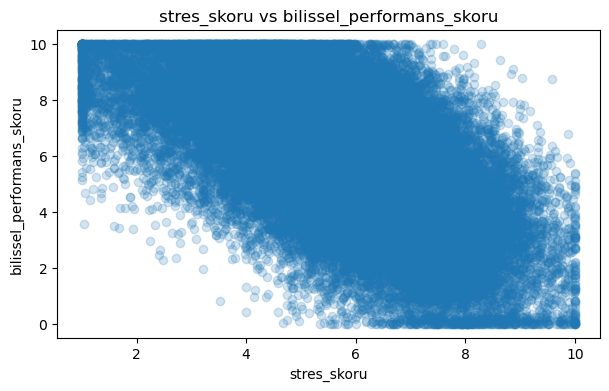

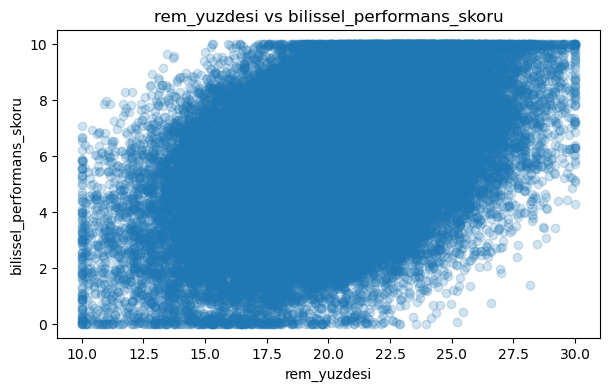

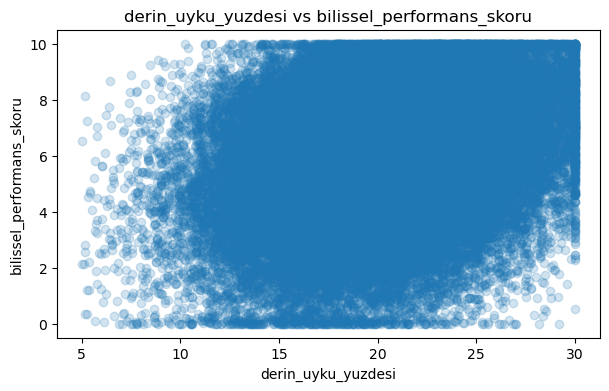

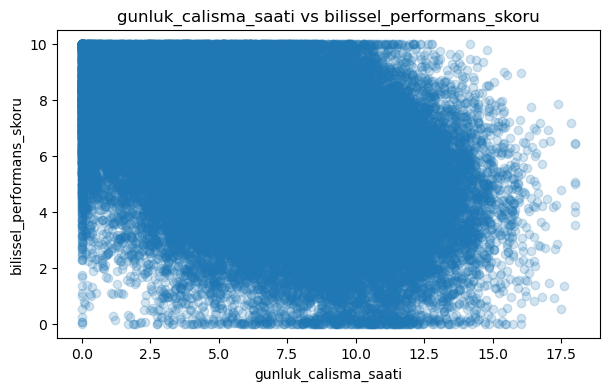

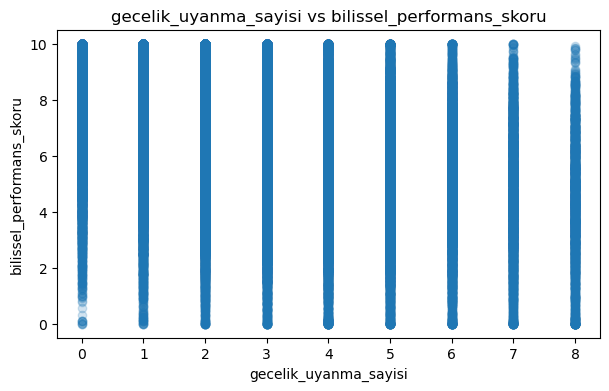

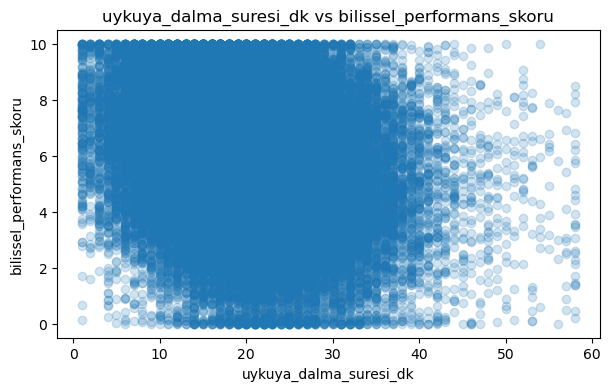

In [30]:
important_numeric_cols = [
    "stres_skoru",
    "rem_yuzdesi",
    "derin_uyku_yuzdesi",
    "gunluk_calisma_saati",
    "gecelik_uyanma_sayisi",
    "uykuya_dalma_suresi_dk"
]

for col in important_numeric_cols:
    if col in train.columns:
        plt.figure(figsize=(7, 4))
        plt.scatter(train[col], train[TARGET], alpha=0.2)
        plt.title(f"{col} vs {TARGET}")
        plt.xlabel(col)
        plt.ylabel(TARGET)
        plt.show()

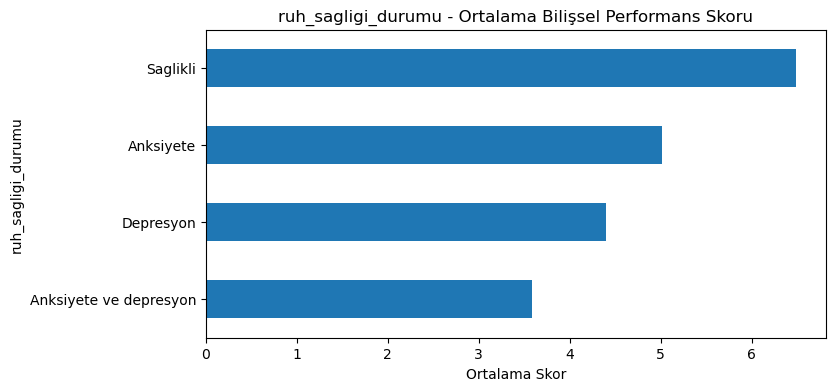

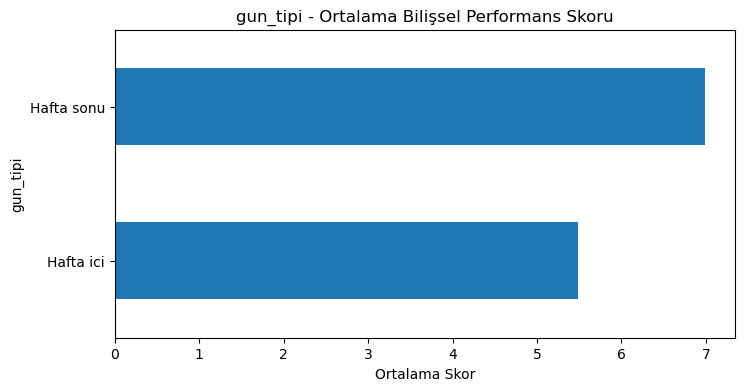

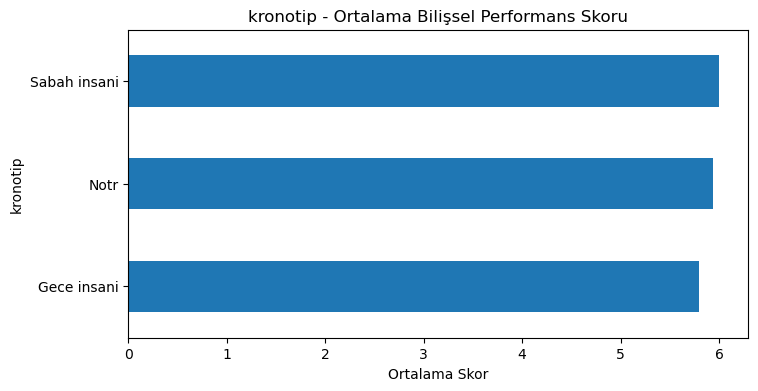

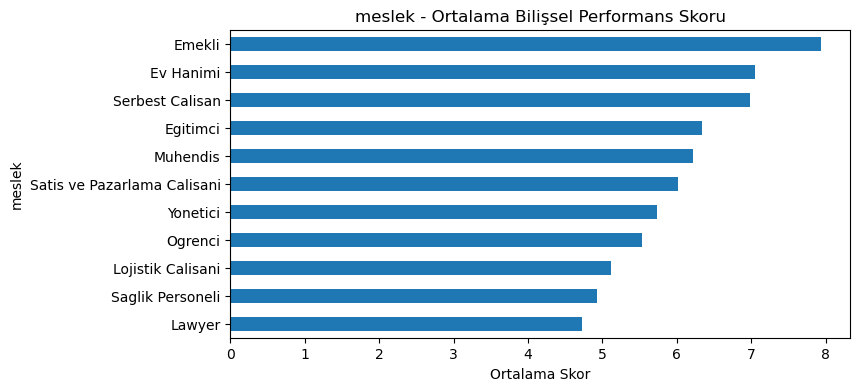

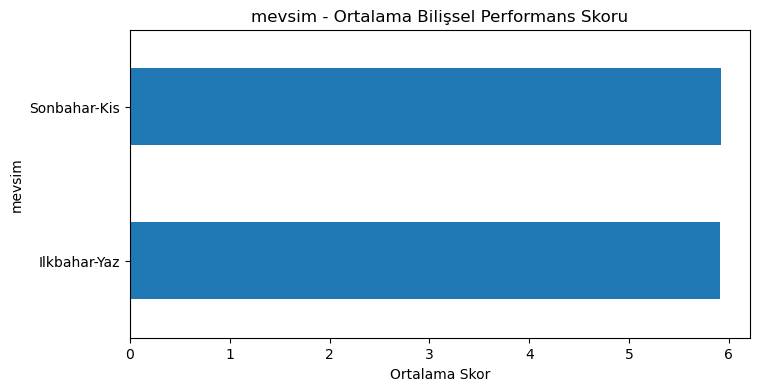

In [31]:
important_categorical_cols = [
    "ruh_sagligi_durumu",
    "gun_tipi",
    "kronotip",
    "meslek",
    "mevsim"
]

for col in important_categorical_cols:
    if col in train.columns:
        means = train.groupby(col)[TARGET].mean().sort_values()

        plt.figure(figsize=(8, 4))
        means.plot(kind="barh")
        plt.title(f"{col} - Ortalama Bilişsel Performans Skoru")
        plt.xlabel("Ortalama Skor")
        plt.ylabel(col)
        plt.show()